In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency,ttest_ind
sns.set(style="whitegrid")

In [3]:
credit = pd.read_csv(r'C:\Users\User\Desktop\exercises\credit card\credit_record.csv')
credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [4]:
application = pd.read_csv(r'C:\Users\User\Desktop\exercises\credit card\application_record.csv')
application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [5]:
credit.shape

(1048575, 3)

In [6]:
application.shape

(438557, 18)

In [7]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [8]:
application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

In [9]:
application.dtypes

ID                       int64
CODE_GENDER             object
FLAG_OWN_CAR            object
FLAG_OWN_REALTY         object
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE        object
NAME_EDUCATION_TYPE     object
NAME_FAMILY_STATUS      object
NAME_HOUSING_TYPE       object
DAYS_BIRTH               int64
DAYS_EMPLOYED            int64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE         object
CNT_FAM_MEMBERS        float64
dtype: object

In [10]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [11]:
application_desc = application.describe()
application_desc = application_desc.applymap(lambda x: '{:.0f}'.format(x))  # Format only for display
application_desc

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS
count,438557,438557,438557,438557,438557,438557,438557,438557,438557,438557
mean,6022176,0,187524,-15998,60564,1,0,0,0,2
std,571637,1,110087,4185,138768,0,0,0,0,1
min,5008804,0,26100,-25201,-17531,1,0,0,0,1
25%,5609375,0,121500,-19483,-3103,1,0,0,0,2
50%,6047745,0,160780,-15630,-1467,1,0,0,0,2
75%,6456971,1,225000,-12514,-371,1,0,1,0,3
max,7999952,19,6750000,-7489,365243,1,1,1,1,20


In [12]:
credit_desc = credit.describe()
credit_desc = credit_desc.applymap(lambda x: '{:.0f}'.format(x))
credit_desc

,ID,MONTHS_BALANCE
count,1048575,1048575
mean,5068286,-19
std,46151,14
min,5001711,-60
25%,5023644,-29
50%,5062104,-17
75%,5113856,-7
max,5150487,0


In [13]:
credit.isnull().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

In [14]:
application.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

In [15]:
#Fill in missin alues
application['OCCUPATION_TYPE'] = application['OCCUPATION_TYPE'] .fillna("Unknown")

In [16]:
#To check for duplicated records

In [17]:
credit.duplicated().sum()

0

In [18]:
application.duplicated().sum()

0

In [19]:
Merged_df = application.merge(credit,on="ID",how="left")

In [20]:
Merged_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,0.0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,-1.0,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,-2.0,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,-3.0,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,-4.0,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1179810,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,-22717,365243,1,0,0,0,Unknown,1.0,NaN,NaN
1179811,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,-15939,-3007,1,0,0,0,Laborers,1.0,NaN,NaN
1179812,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,-8169,-372,1,1,0,0,Sales staff,1.0,NaN,NaN
1179813,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21673,365243,1,0,0,0,Unknown,2.0,NaN,NaN


In [21]:
Merged_df.describe().applymap(lambda x:'{:.0f}'.format(x))

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,MONTHS_BALANCE
count,1179815,1179815,1179815,1179815,1179815,1179815,1179815,1179815,1179815,1179815,777715
mean,5429449,0,188216,-16082,58766,1,0,0,0,2,-19
std,574823,1,104844,4132,137300,0,0,0,0,1,14
min,5008804,0,26100,-25201,-17531,1,0,0,0,1,-60
25%,5061203,0,121500,-19473,-3242,1,0,0,0,2,-29
50%,5115961,0,162000,-15711,-1617,1,0,0,0,2,-17
75%,5769826,1,225000,-12646,-412,1,0,1,0,3,-8
max,7999952,19,6750000,-7489,365243,1,1,1,1,20,0


In [22]:
#Feature Enineering
print(Merged_df.columns)
#Age

Merged_df['Age'] = (-Merged_df['DAYS_BIRTH']/365).astype(int)
Merged_df.head()

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'MONTHS_BALANCE',
       'STATUS'],
      dtype='object')


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,Age
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,0.0,C,32
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,-1.0,C,32
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,-2.0,C,32
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,-3.0,C,32
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,Unknown,2.0,-4.0,C,32


In [23]:
#Employment Years
Merged_df['EMPLOYMENT_YEARS'] = (-Merged_df['DAYS_EMPLOYED'].replace(365243,np.nan)/365)
Merged_df

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,Age,EMPLOYMENT_YEARS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,0.0,C,32,12.443836
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,-1.0,C,32,12.443836
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,-2.0,C,32,12.443836
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,-3.0,C,32,12.443836
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,-4.0,C,32,12.443836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1179810,6840104,M,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Separated,House / apartment,...,1,0,0,0,Unknown,1.0,NaN,NaN,62,NaN
1179811,6840222,F,N,N,0,103500.0,Working,Secondary / secondary special,Single / not married,House / apartment,...,1,0,0,0,Laborers,1.0,NaN,NaN,43,8.238356
1179812,6841878,F,N,N,0,54000.0,Commercial associate,Higher education,Single / not married,With parents,...,1,1,0,0,Sales staff,1.0,NaN,NaN,22,1.019178
1179813,6842765,F,N,Y,0,72000.0,Pensioner,Secondary / secondary special,Married,House / apartment,...,1,0,0,0,Unknown,2.0,NaN,NaN,59,NaN


In [24]:
#Income Category
Merged_df['INCOME_CATEGORY'] = pd.cut(Merged_df['AMT_INCOME_TOTAL'],bins=[0,50000,100000,200000,500000,2000000],labels=["Low","Lower-Middle","Middle","Upper-Middle","High"])
Merged_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,Age,EMPLOYMENT_YEARS,INCOME_CATEGORY
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,0,0,Unknown,2.0,0.0,C,32,12.443836,Upper-Middle
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,0,0,Unknown,2.0,-1.0,C,32,12.443836,Upper-Middle
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,0,0,Unknown,2.0,-2.0,C,32,12.443836,Upper-Middle
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,0,0,Unknown,2.0,-3.0,C,32,12.443836,Upper-Middle
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,0,0,Unknown,2.0,-4.0,C,32,12.443836,Upper-Middle


In [25]:
#Descriptive Stattistics
Merged_df.describe().applymap(lambda x: '{:.0f}'.format(x))  # Format only for display

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,MONTHS_BALANCE,Age,EMPLOYMENT_YEARS
count,1179815,1179815,1179815,1179815,1179815,1179815,1179815,1179815,1179815,1179815,777715,1179815,982649
mean,5429449,0,188216,-16082,58766,1,0,0,0,2,-19,44,7
std,574823,1,104844,4132,137300,0,0,0,0,1,14,11,7
min,5008804,0,26100,-25201,-17531,1,0,0,0,1,-60,20,0
25%,5061203,0,121500,-19473,-3242,1,0,0,0,2,-29,34,3
50%,5115961,0,162000,-15711,-1617,1,0,0,0,2,-17,43,6
75%,5769826,1,225000,-12646,-412,1,0,1,0,3,-8,53,10
max,7999952,19,6750000,-7489,365243,1,1,1,1,20,0,69,48


In [26]:
Merged_df.describe(include="object")

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,STATUS
count,1179815,1179815,1179815,1179815,1179815,1179815,1179815,1179815,777715
unique,2,2,2,5,5,5,6,19,8
top,F,N,Y,Working,Secondary / secondary special,Married,House / apartment,Unknown,C
freq,788861,726200,792516,607449,801305,821399,1058434,362928,329536


In [27]:
#Frequnecy Distibution
Merged_df['CODE_GENDER'].value_counts()

F    788861
M    390954
Name: CODE_GENDER, dtype: int64

In [28]:
Merged_df['NAME_INCOME_TYPE'].value_counts()

Working                 607449
Commercial associate    275652
Pensioner               197733
State servant            98638
Student                    343
Name: NAME_INCOME_TYPE, dtype: int64

In [29]:
Merged_df['NAME_EDUCATION_TYPE'].value_counts()

Secondary / secondary special    801305
Higher education                 321291
Incomplete higher                 43770
Lower secondary                   12332
Academic degree                    1117
Name: NAME_EDUCATION_TYPE, dtype: int64

In [30]:
Merged_df['NAME_FAMILY_STATUS'].value_counts()

Married                 821399
Single / not married    144777
Civil marriage           93929
Separated                70403
Widow                    49307
Name: NAME_FAMILY_STATUS, dtype: int64

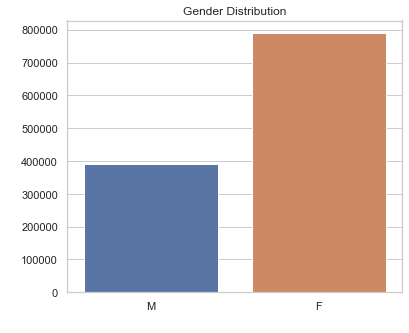

In [31]:
#Visualiation - CODE_GENDER
#Is credit application behavior different between genders?
plt.figure(figsize=(6,5))
sns.countplot(x='CODE_GENDER',data=Merged_df)
plt.title("Gender Distribution")
plt.xlabel(" ")
plt.ylabel(" ")
plt.show()

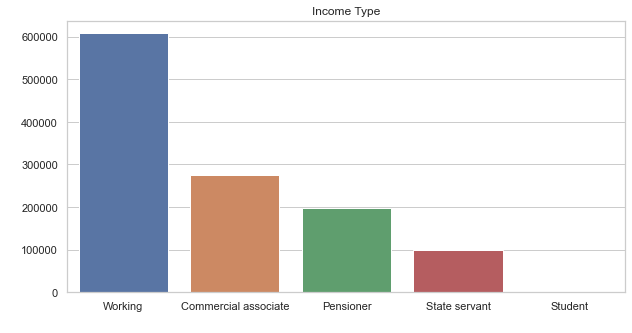

In [32]:
#INCOME_TYPE
#Which employment categories apply for credit most frequently?
plt.figure(figsize=(10,5))
sns.countplot(x='NAME_INCOME_TYPE',data=Merged_df,order=Merged_df['NAME_INCOME_TYPE'].value_counts().index)
plt.title("Income Type")
plt.xlabel(" ")
plt.ylabel(" ")
plt.show()

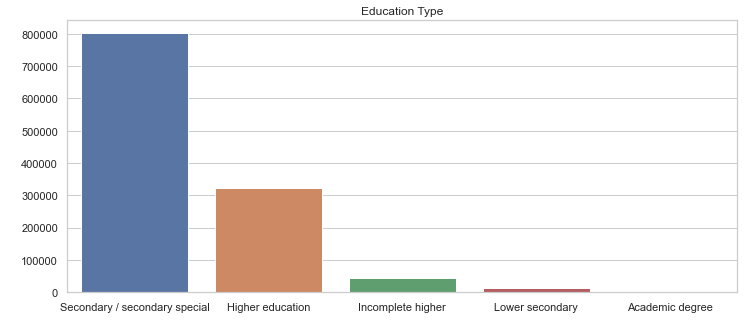

In [33]:
#EDUCATION
#Which eduction level are common among applicants?
plt.figure(figsize=(12,5))
sns.countplot(x='NAME_EDUCATION_TYPE',data=Merged_df,order=Merged_df['NAME_EDUCATION_TYPE'].value_counts().index)
plt.title("Education Type")
plt.xlabel(" ")
plt.ylabel(" ")
plt.show()

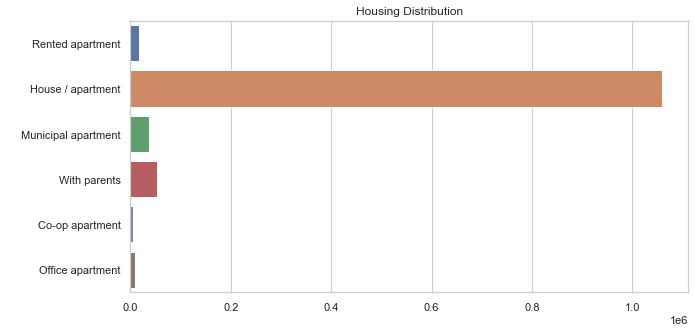

In [34]:
#HOUSING
#Which type of housing do most applicants have?
plt.figure(figsize=(10,5))
sns.countplot(y='NAME_HOUSING_TYPE',data=Merged_df)
plt.title("Housing Distribution")
plt.xlabel(" ")
plt.ylabel(" ")
plt.show()

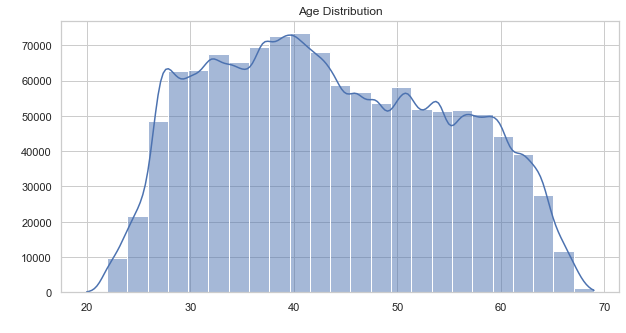

In [35]:
#Aging Distribution - Are young or older applicants more likeliy to seek credit?
plt.figure(figsize=(10,5))
sns.histplot(Merged_df['Age'],bins=25,kde=True)
plt.title("Age Distribution")
plt.xlabel(" ")
plt.ylabel(" ")
plt.show()

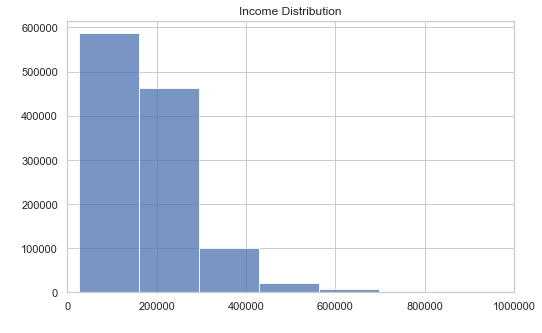

In [36]:
#Income Distribution - Which income ranges dominates?
plt.figure(figsize=(8,5))
sns.histplot(Merged_df['AMT_INCOME_TOTAL'],bins=50)
plt.xlim(0,1000000)
plt.title("Income Distribution")
plt.xlabel(" ")
plt.ylabel(" ")
plt.ticklabel_format(style='plain',axis='x')   #remove scientific notation
plt.show()

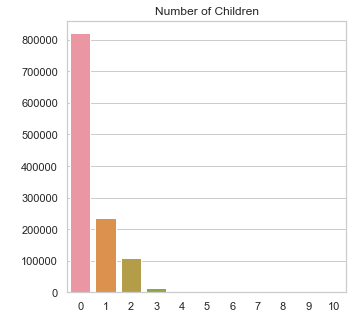

In [37]:
#Children Distribution - Does number of childern affect financial obligations?
plt.figure(figsize=(5,5))
ax=sns.countplot(x='CNT_CHILDREN',data=Merged_df,order=range(11))
plt.title("Number of Children")
plt.xlabel(" ")
plt.ylabel(" ")
plt.show()

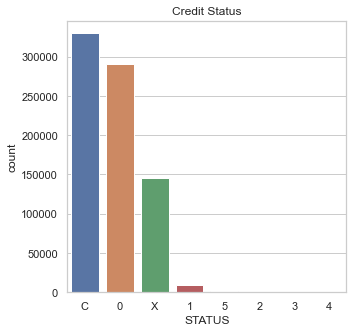

In [38]:
#Credit Status Distribution - What is the distribution of credit repayment statues?
plt.figure(figsize=(5,5))
sns.countplot(x='STATUS',data=Merged_df,order=Merged_df['STATUS'].value_counts().index)
plt.title("Credit Status")
plt.show()

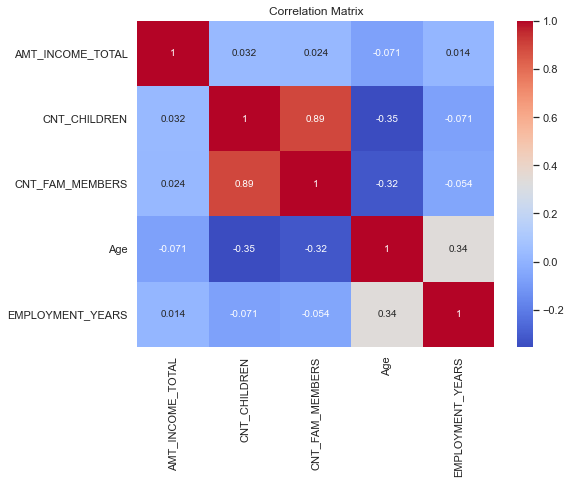

,AMT_INCOME_TOTAL,CNT_CHILDREN,CNT_FAM_MEMBERS,Age,EMPLOYMENT_YEARS
AMT_INCOME_TOTAL,1.000000,0.031708,0.023890,-0.070637,0.014475
CNT_CHILDREN,0.031708,1.000000,0.889474,-0.353814,-0.070994
CNT_FAM_MEMBERS,0.023890,0.889474,1.000000,-0.320143,-0.054033
Age,-0.070637,-0.353814,-0.320143,1.000000,0.335607
EMPLOYMENT_YEARS,0.014475,-0.070994,-0.054033,0.335607,1.000000


In [39]:
#Correlation - Does Age correlate with employment experience?
num = Merged_df[['AMT_INCOME_TOTAL','CNT_CHILDREN','CNT_FAM_MEMBERS','Age','EMPLOYMENT_YEARS']]
corr = num.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
corr

#Key FIndings
1. Chidren & family members have a very strong relationship(0.8)
Applicants with more children usually have larger family sizes.
For ML models keeping both may introduce multicollinearlity, espically for linear models.
2. Age & number of children have a moderate negative relationship.
Younger appplicants tend to have more children compared with older applicants.
However, this is only a relationship, not a cause.
3. Age & employement years have a moderate positive relationship.
Older applicants generally have more years of employemt experience.
4. Income has very weak correlation with other variables.
Example Income vs Age : -0.0706
    Income vs Employment Years = 0.0145
This means income does not show a strong linear relationship with age,employment duration, number of children or family size.

In [40]:
#Chi-Sqaure test
#Gender vs Car OwnerShip - Is there a significant relationship between appicant gender & car ownership?
#Hypothesis:
 #   H0: Gender & car ownership are independdent.
 #  H1: Gender & car ownership are related.
table = pd.crosstab(Merged_df['CODE_GENDER'],Merged_df['FLAG_OWN_CAR'])
chi2,p,dof,expected = chi2_contingency(table)
print("Chi Square :",chi2)
print("p value :",p)

Chi Square : 153486.30551080132
p value : 0.0


p-value = 0.0, this means the p-value is extremely small(smaller than the precison python displays), usually p>0.001. 
Since p-value <0.05 we reject the null hypothesis.
Conclusion there is a statistically significant association between ender &  car ownership. The pattern owning a car differs \\
significantly between male & female applicants.

Dataset has 1.18 million rows. With such a large sample size,even small difference can become statistcially sinificant.
So, check strenth of association, not only sinificance. For example,calculate, Cramer's V:

In [41]:
n = table.sum().sum()
phi2 = chi2/n
r,k = table.shape
cramers_v = np.sqrt(phi2/min(k-1,r-1))
print("Cramer's V :",cramers_v)

Cramer's V : 0.3606848157102126


The analysis found that male & female applicants have differeent patterns of car ownership. The difference is stratistically 
significant,meaning it is unlikely to be due to random chance. However the relationship strength is moderate, so gender alone 
does not fully explain car ownership; other customer characterstics may also play an important role.

In [42]:
pd.crosstab(Merged_df['CODE_GENDER'],Merged_df['FLAG_OWN_CAR'],normalize='index')*100

FLAG_OWN_CAR,N,Y
CODE_GENDER,,
F,73.904401,26.095599
M,36.627583,63.372417


Male applicants have a much higher rate of car ownership compared with female applicants. Around 2/3rd of male applicants own a 
car, while only about 1/3 of female applicants owns a car.
Car ownership can be considered as a customer profile feature but it should not be interpreted as a direct cause of creditworthiness.
Other factors such as income,employment and credit hostory should also be considered.

In [43]:
#T-Test
#Is there a significant difference in avearge income between male & female applicants?
#Hypothesis
# H0: Male & feamle applicants have equal average income
# H1: Their average incomes are significantly different
#Male vs Female Income
male = Merged_df[Merged_df['CODE_GENDER']=='M']['AMT_INCOME_TOTAL']
female = Merged_df[Merged_df['CODE_GENDER']=='F']['AMT_INCOME_TOTAL']
t,p = ttest_ind(male,female,equal_var=False)
print("T-Test")
print("Statistic :",t)
print("p Value",p)

T-Test
Statistic : 196.38152624088883
p Value 0.0


Compared the average income of male and female applicants. The results showed a statistcially significant difference between
the two groups.This indicates that the male & female applicants have different income distribution in the dataset.

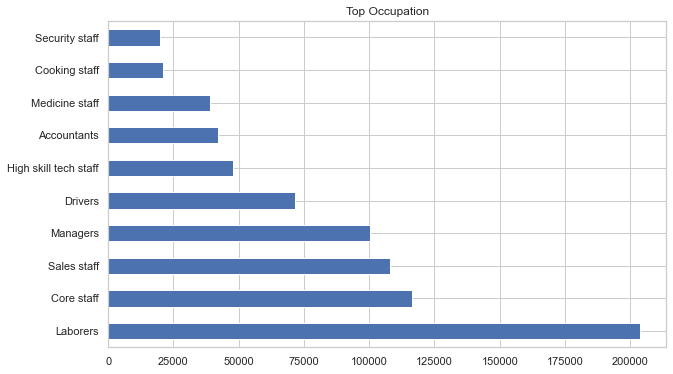

In [44]:
#Top Occupation - Does occupation type indicate financial stability
Merged_df_occupation = Merged_df[Merged_df['OCCUPATION_TYPE'] != 'Unknown']
plt.figure(figsize=(10,6))
Merged_df_occupation['OCCUPATION_TYPE'].value_counts().head(10).plot(kind="barh")
plt.title("Top Occupation")
plt.show()

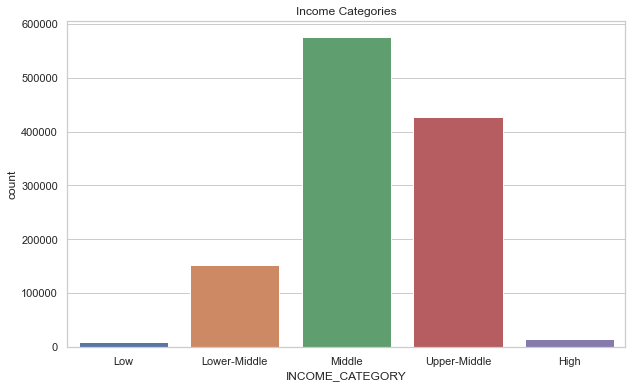

In [45]:
#Income category - Which income group contains most applicants?
plt.figure(figsize=(10,6))
sns.countplot(x='INCOME_CATEGORY',data=Merged_df)
plt.title("Income Categories")
plt.show()

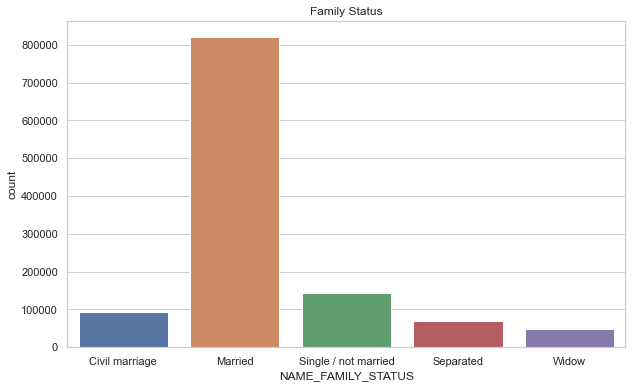

In [46]:
#Family Status - Does family status affect?
plt.figure(figsize=(10,6))
sns.countplot(x='NAME_FAMILY_STATUS',data=Merged_df)
plt.title("Family Status")
plt.show()

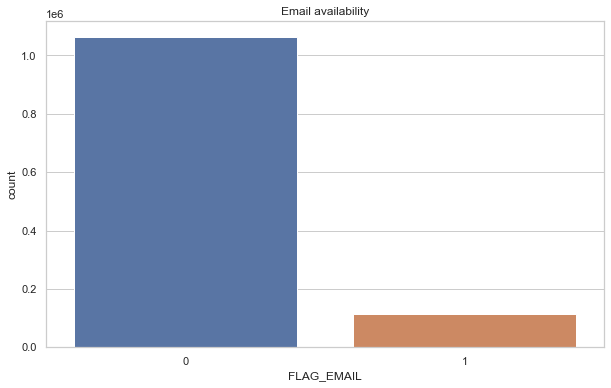

In [47]:
#Mobile/Email - How many applicants hae registered Email?
plt.figure(figsize=(10,6))
sns.countplot(x='FLAG_EMAIL',data=Merged_df)
plt.title("Email availability")
plt.show()

In [48]:
#Summary Table - What is the typical applicants's age & income
summary = pd.DataFrame({
    'Mean' :[Merged_df['Age'].mean(),Merged_df['AMT_INCOME_TOTAL'].mean()],
    'Median' :[Merged_df['Age'].median(),Merged_df['AMT_INCOME_TOTAL'].median()],
    'Std' :[Merged_df['Age'].std(),Merged_df['AMT_INCOME_TOTAL'].std()]
},
index=['Age','Income'])
print(summary)

                 Mean    Median            Std
Age         43.555844      43.0      11.322510
Income  188216.313569  162000.0  104844.453399


In [49]:
#Save Cleaned Dataset
Merged_df.to_csv("Credit_Cleaned.csv",index=False)
print("\n Analysis Completed Successfully!!!")


 Analysis Completed Successfully!!!


In [50]:
#Check Outliers
Merged_df['AMT_INCOME_TOTAL'].describe().map(lambda x:'{:.0f}'.format(x))

count    1179815
mean      188216
std       104844
min        26100
25%       121500
50%       162000
75%       225000
max      6750000
Name: AMT_INCOME_TOTAL, dtype: object

Large difference between 75% (225000) and Max(675000). This indicates that the mean is much higher than the median.
This means right skew & possible outliers

In [51]:
#IQR method
Q1 = Merged_df['AMT_INCOME_TOTAL'].quantile(0.25)
Q3 = Merged_df['AMT_INCOME_TOTAL'].quantile(0.75)
IQR = Q3-Q1
lower_limit = Q1 - IQR*1.5
upper_limit = Q3 + IQR*1.5

outliers = Merged_df[(Merged_df['AMT_INCOME_TOTAL'] < lower_limit) | (Merged_df['AMT_INCOME_TOTAL'] >  upper_limit)]
print("Number of outliers:",len(outliers))

Number of outliers: 51566


In [52]:
# Percentage of Outliers
print((len(outliers)/len(Merged_df)*100))

4.370685234549485


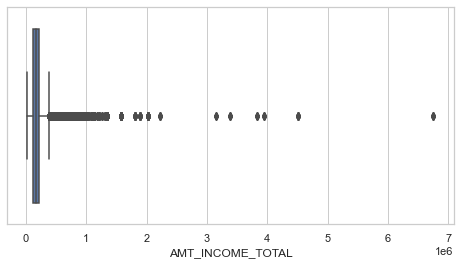

In [53]:
#BoxPlot
plt.figure(figsize=(8,4))
sns.boxplot(x=Merged_df['AMT_INCOME_TOTAL'])
plt.show()